# Разведочный анализ данных: CIFAR-10 (изображения)

Базовый EDA для датасета CIFAR-10 (папка `cifar/cifar10/train`): просмотр примеров изображений по классам и усреднённого изображения.


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Пути к данным
DATA_DIR = os.path.join("..", "datasets", "cifar", "cifar10")
TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR = os.path.join(DATA_DIR, "test")

def load_cifar10_from_folders(root_dir, max_per_class=None):
    """
    Загружает все изображения из папок классов.
    max_per_class: если указано, берёт не более указанного числа из каждого класса.
    Возвращает: images (N, H, W, C) uint8, labels (N,) int, class_names list
    """
    class_names = sorted(os.listdir(root_dir))
    images = []
    labels = []
    for label, cls in enumerate(class_names):
        cls_dir = os.path.join(root_dir, cls)
        if not os.path.isdir(cls_dir):
            continue
        fnames = [f for f in os.listdir(cls_dir)
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if max_per_class is not None:
            fnames = fnames[:max_per_class]
        for fname in fnames:
            path = os.path.join(cls_dir, fname)
            try:
                img = Image.open(path).convert("RGB")
                images.append(np.array(img, dtype=np.uint8))
                labels.append(label)
            except Exception:
                continue
    return np.array(images), np.array(labels), class_names

# Загружаем тренировочные данные (для полного анализа – все 50000)
train_images, train_labels, class_names = load_cifar10_from_folders(TRAIN_DIR, max_per_class=None)
print(f"Загружено изображений: {train_images.shape[0]}, размер: {train_images.shape[1:]}")


Загружено изображений: 50000, размер: (32, 32, 3)


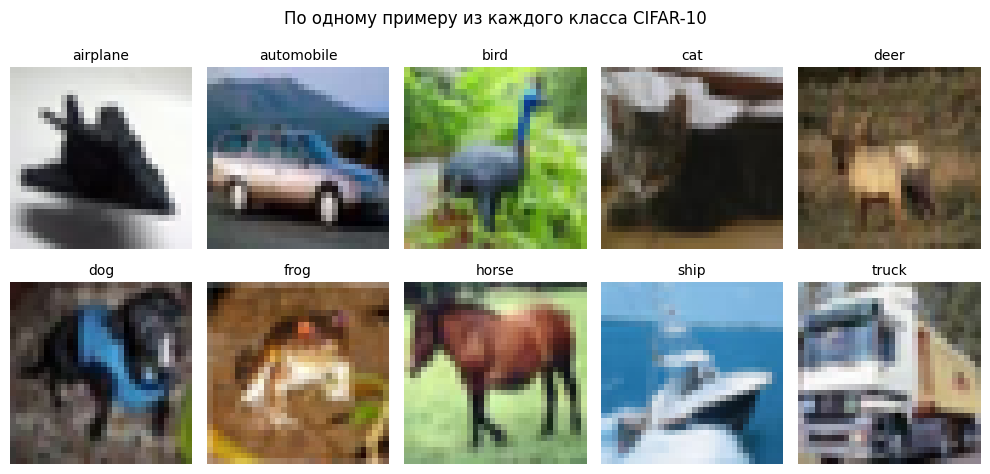

In [2]:
# --------------------------------------------------------------------------------
# 1. Примеры изображений – по одному на каждый класс (2x5)
# --------------------------------------------------------------------------------
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.flatten()
for i in range(10):
    # Берём первое изображение i-го класса
    idx = np.where(train_labels == i)[0][0]
    axes[i].imshow(train_images[idx])
    axes[i].set_title(class_names[i], fontsize=10)
    axes[i].axis("off")
plt.suptitle("По одному примеру из каждого класса CIFAR-10")
plt.tight_layout()
plt.show()

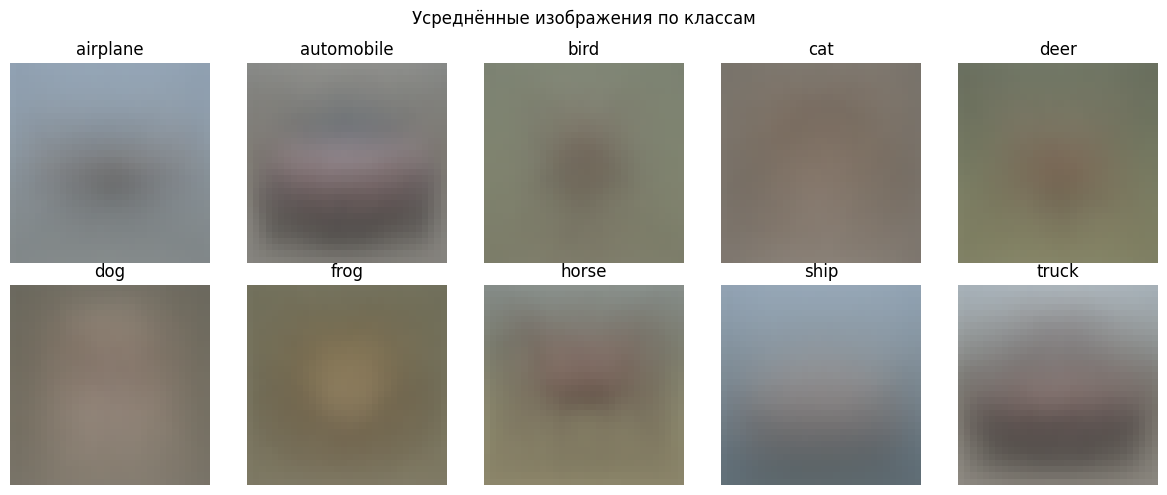

In [3]:
# --------------------------------------------------------------------------------
# 2. Усреднённые изображения для каждого класса (главное улучшение)
# --------------------------------------------------------------------------------
mean_per_class = []
for digit in range(10):
    class_imgs = train_images[train_labels == digit]
    mean_img = class_imgs.mean(axis=0).astype(np.uint8) if len(class_imgs) > 0 else np.zeros_like(train_images[0])
    mean_per_class.append(mean_img)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()
for i, ax in enumerate(axes):
    ax.imshow(mean_per_class[i])
    ax.set_title(class_names[i])
    ax.axis("off")
plt.suptitle("Усреднённые изображения по классам")
plt.tight_layout()
plt.show()

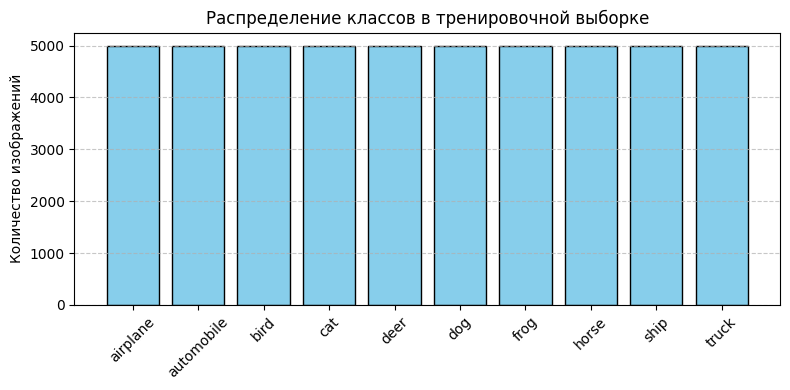

In [4]:
# --------------------------------------------------------------------------------
# 3. Распределение классов (count plot)
# --------------------------------------------------------------------------------
unique, counts = np.unique(train_labels, return_counts=True)
plt.figure(figsize=(8, 4))
plt.bar([class_names[u] for u in unique], counts, color='skyblue', edgecolor='black')
plt.title("Распределение классов в тренировочной выборке")
plt.ylabel("Количество изображений")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

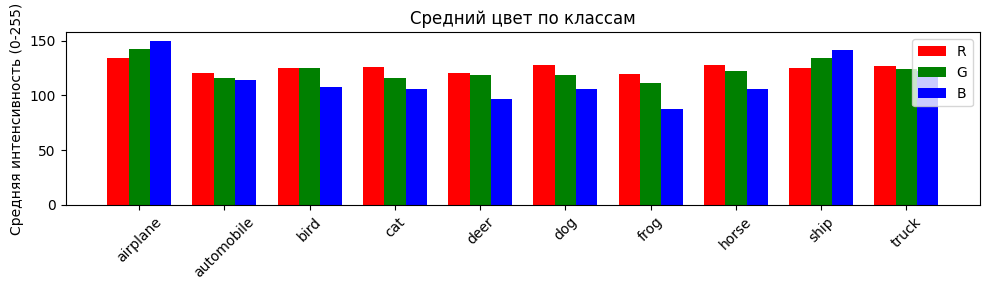

In [5]:
# --------------------------------------------------------------------------------
# 4. Средний цвет (R, G, B) каждого класса
# --------------------------------------------------------------------------------
mean_colors = np.zeros((10, 3))  # R, G, B
for i in range(10):
    class_pixels = train_images[train_labels == i].reshape(-1, 3)
    mean_colors[i] = class_pixels.mean(axis=0)

fig, ax = plt.subplots(figsize=(10, 3))
x = np.arange(10)
width = 0.25
ax.bar(x - width, mean_colors[:, 0], width, color='red', label='R')
ax.bar(x, mean_colors[:, 1], width, color='green', label='G')
ax.bar(x + width, mean_colors[:, 2], width, color='blue', label='B')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45)
ax.set_ylabel("Средняя интенсивность (0-255)")
ax.set_title("Средний цвет по классам")
ax.legend()
plt.tight_layout()
plt.show()

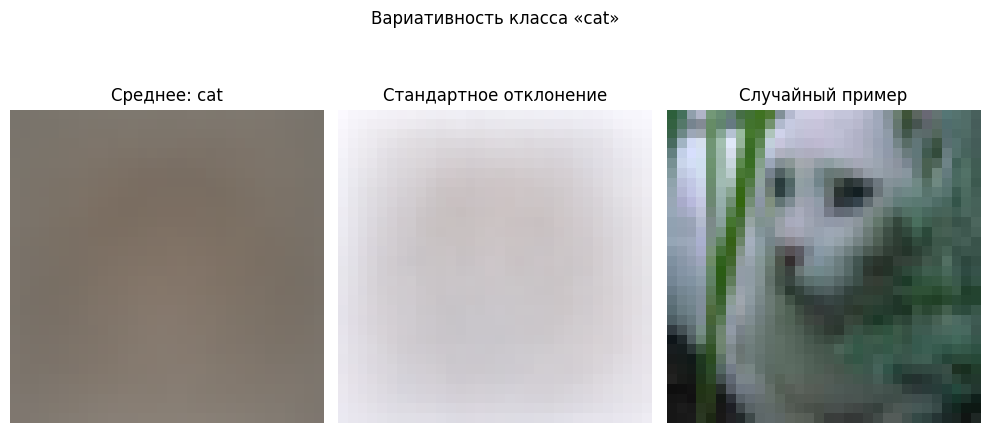

In [6]:
# --------------------------------------------------------------------------------
# 5. Внутриклассовая вариативность: std-изображение и примеры одного класса
# --------------------------------------------------------------------------------
class_idx = 3  # например, cat
class_images = train_images[train_labels == class_idx]
std_img = class_images.std(axis=0)  # (32,32,3)

plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.imshow(mean_per_class[class_idx])
plt.title(f"Среднее: {class_names[class_idx]}")
plt.axis("off")
plt.subplot(1, 3, 2)
# Нормализуем std для визуализации
plt.imshow(std_img / std_img.max())  # относительная яркость
plt.title("Стандартное отклонение")
plt.axis("off")
plt.subplot(1, 3, 3)
# Пример случайного изображения из класса
rand_idx = np.random.randint(0, len(class_images))
plt.imshow(class_images[rand_idx])
plt.title("Случайный пример")
plt.axis("off")
plt.suptitle(f"Вариативность класса «{class_names[class_idx]}»")
plt.tight_layout()
plt.show()

In [11]:
# --------------------------------------------------------------------------------
# 6. PCA-проекция (2D) для небольшой подвыборки, чтобы увидеть структуру классов
# --------------------------------------------------------------------------------
n_sample_per_class = 250
sample_images = []
sample_labels = []
for i in range(10):
    idx = np.where(train_labels == i)[0]
    chosen = np.random.choice(idx, min(n_sample_per_class, len(idx)), replace=False)
    sample_images.append(train_images[chosen])
    sample_labels.append(np.full(len(chosen), i))
sample_images = np.concatenate(sample_images).reshape(-1, 32*32*3)
sample_labels = np.concatenate(sample_labels)

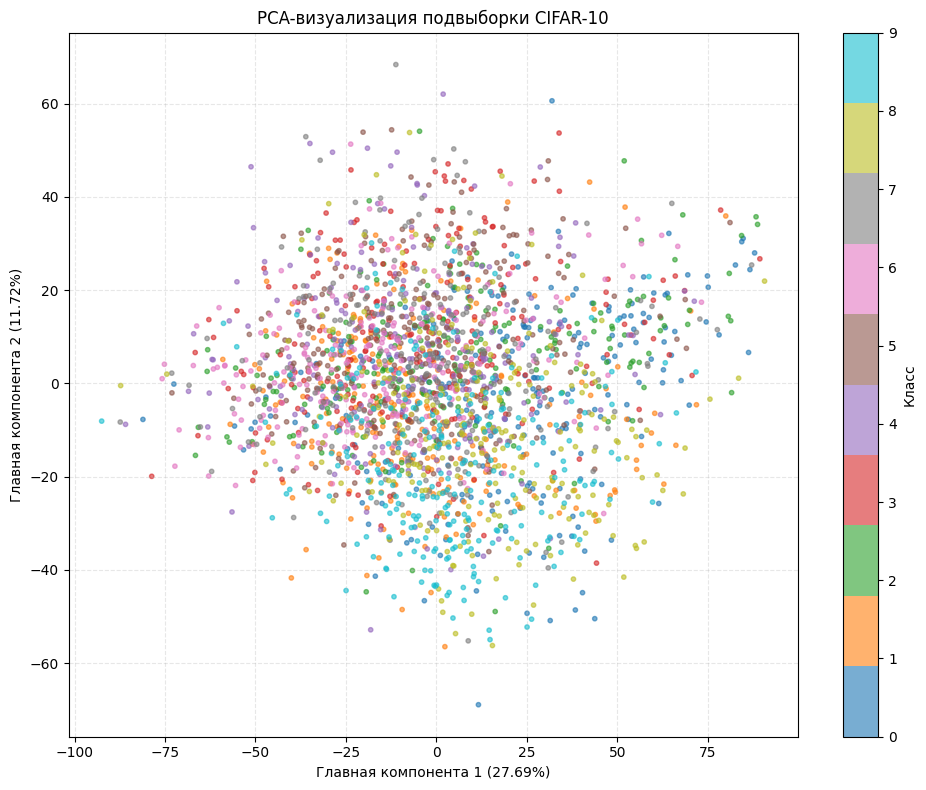

In [12]:
# Стандартизация
scaler = StandardScaler()
sample_images_scaled = scaler.fit_transform(sample_images)
pca = PCA(n_components=2)
components = pca.fit_transform(sample_images_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(components[:, 0], components[:, 1], c=sample_labels, cmap='tab10', alpha=0.6, s=10)
plt.colorbar(scatter, ticks=range(10), label='Класс')
plt.title("PCA-визуализация подвыборки CIFAR-10")
plt.xlabel(f"Главная компонента 1 ({pca.explained_variance_ratio_[0]:.2%})")
plt.ylabel(f"Главная компонента 2 ({pca.explained_variance_ratio_[1]:.2%})")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()